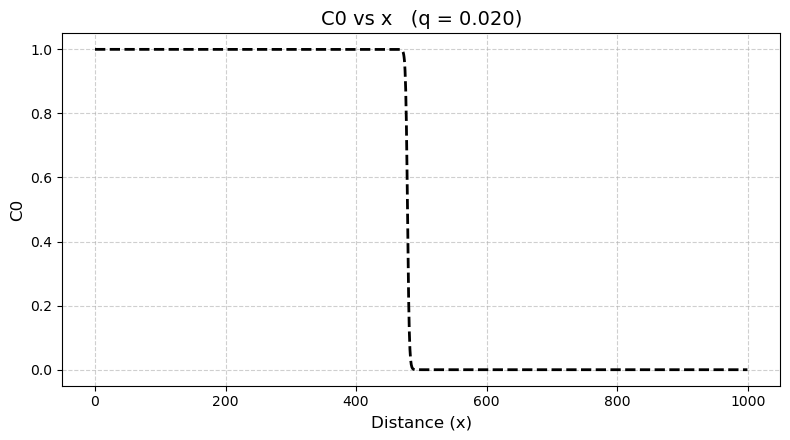

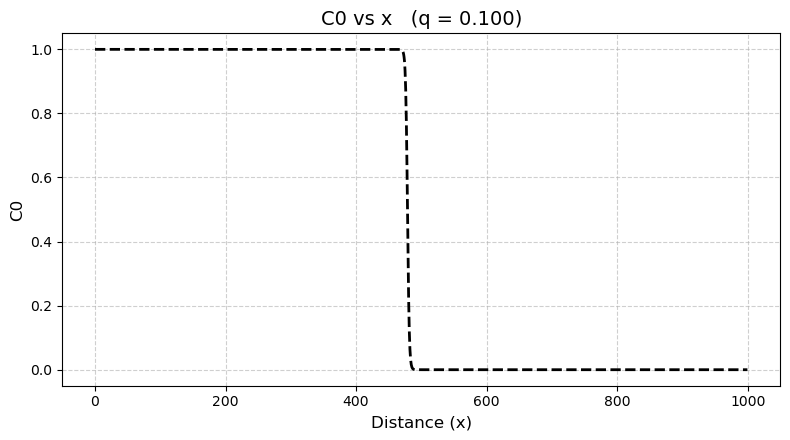

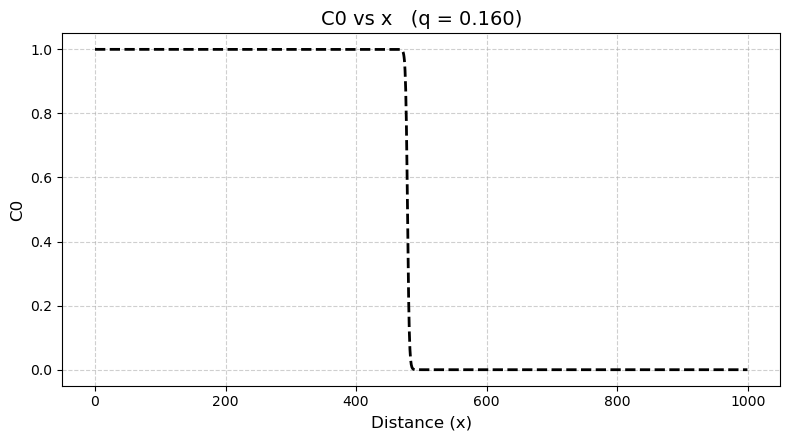

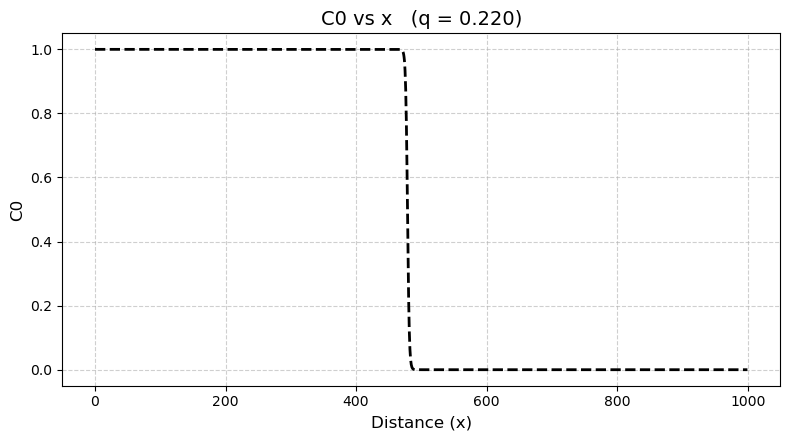

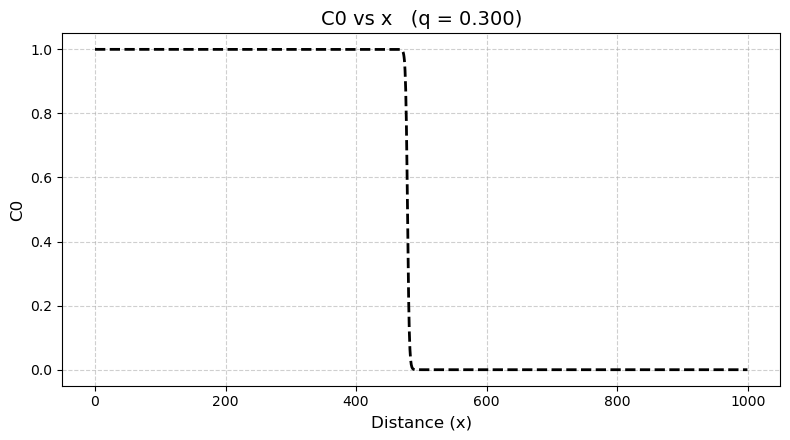

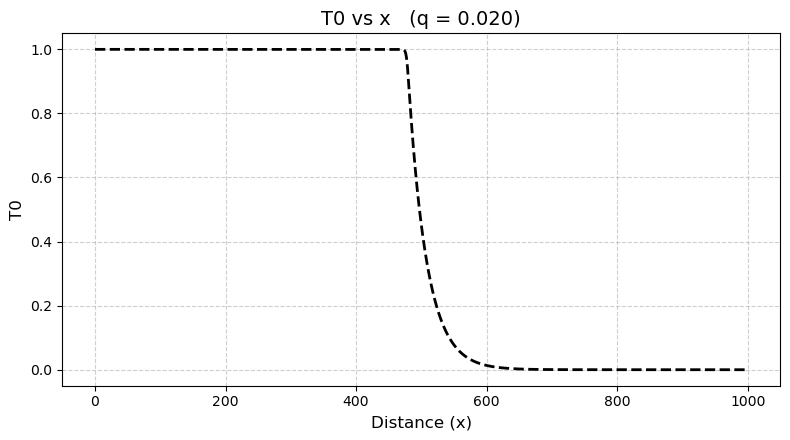

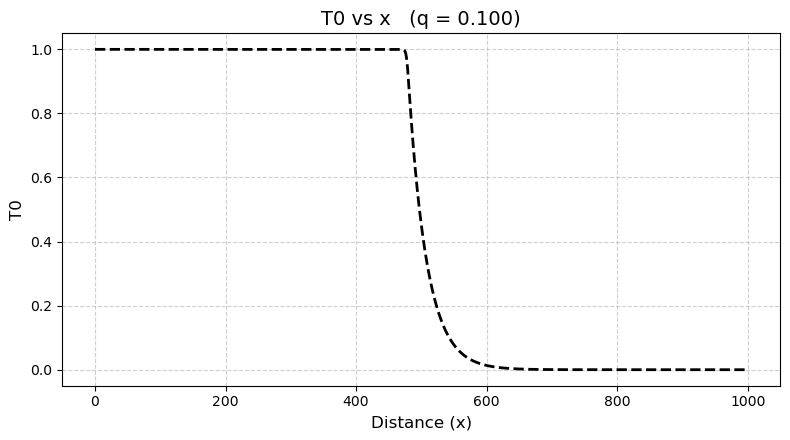

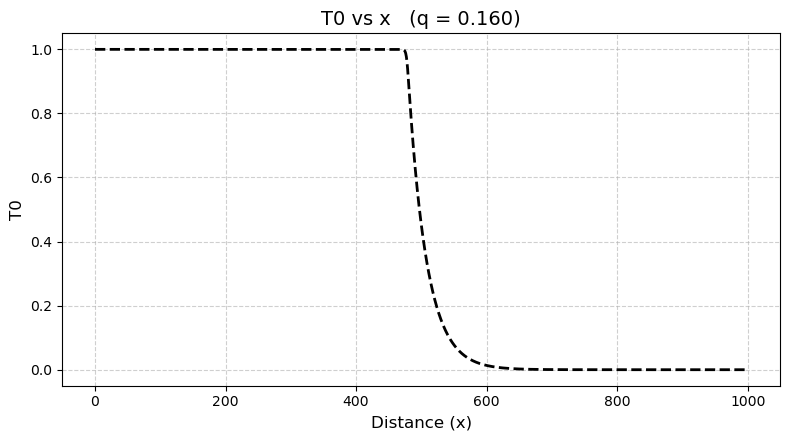

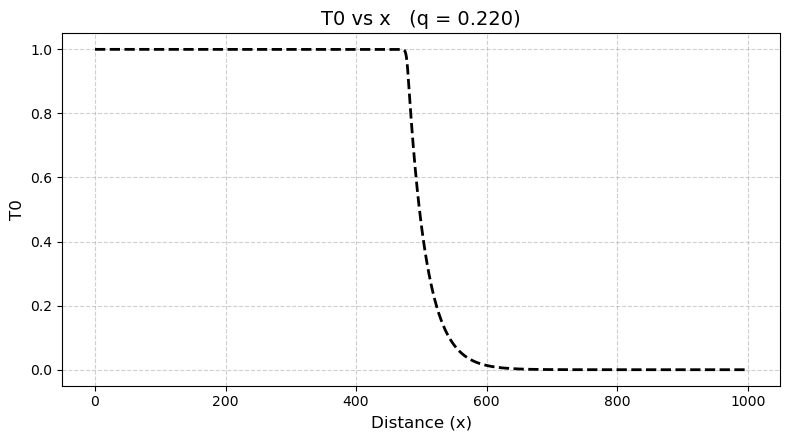

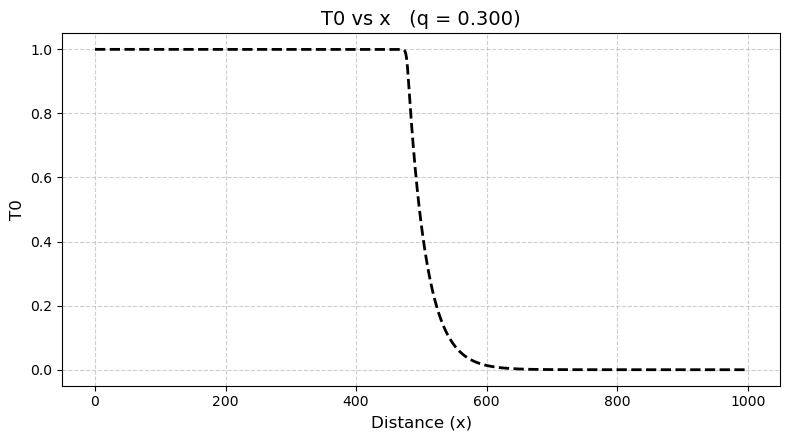

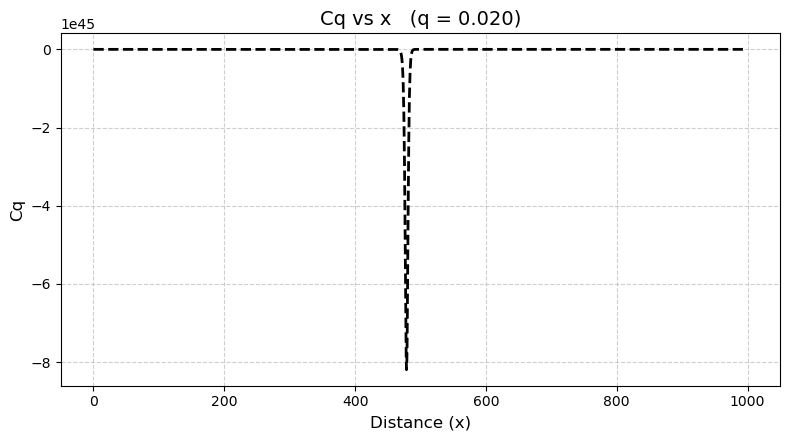

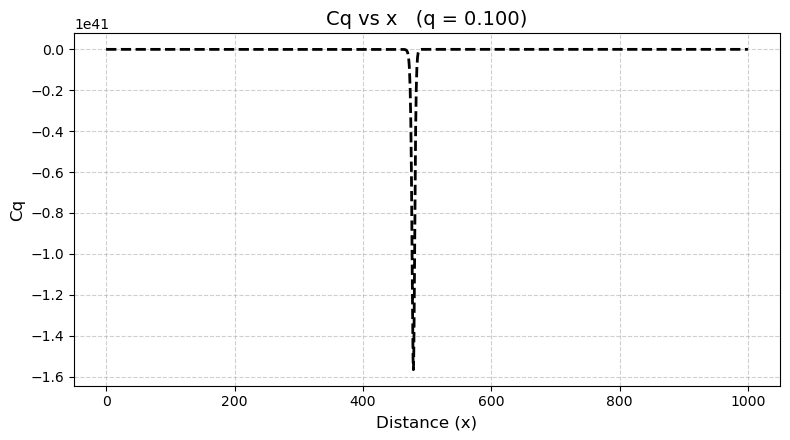

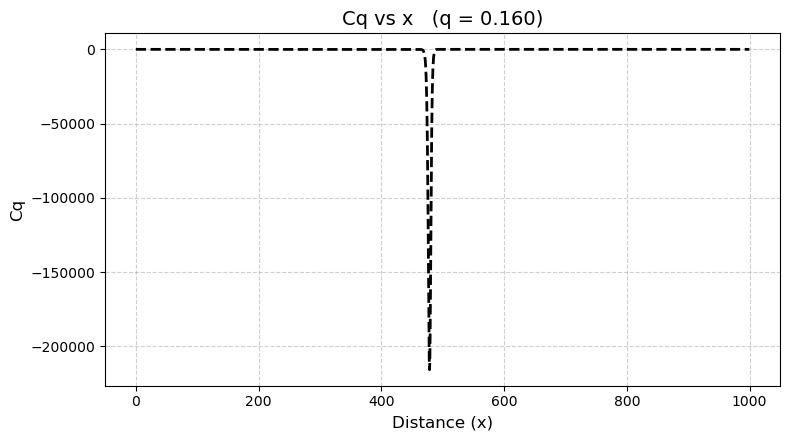

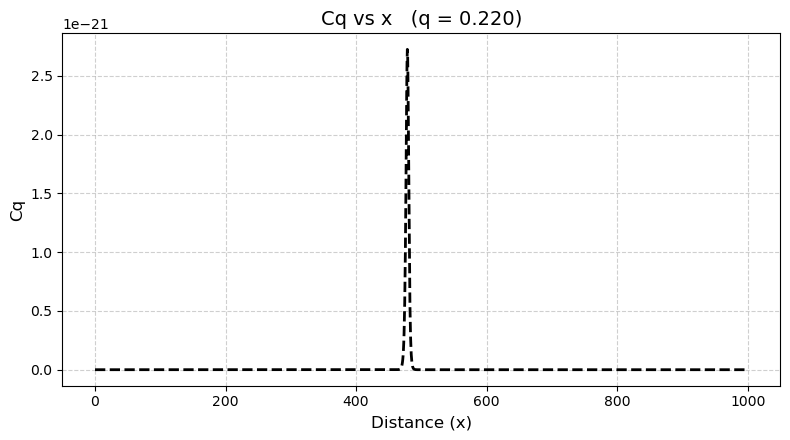

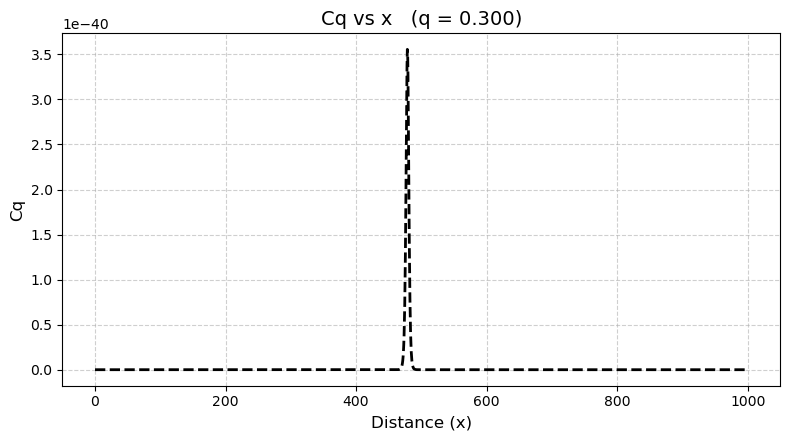

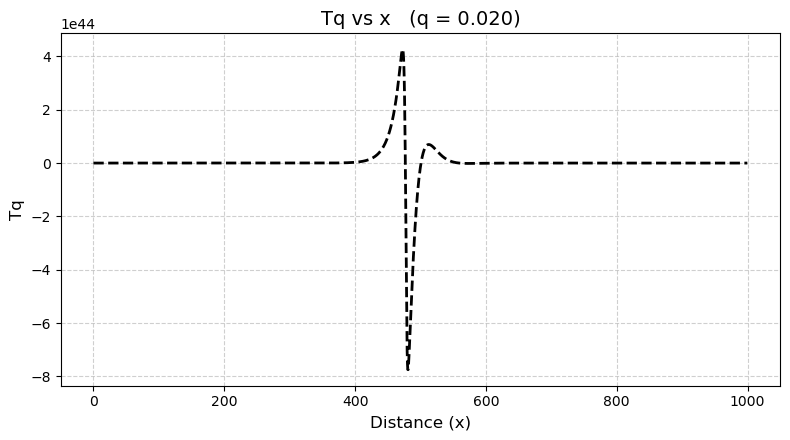

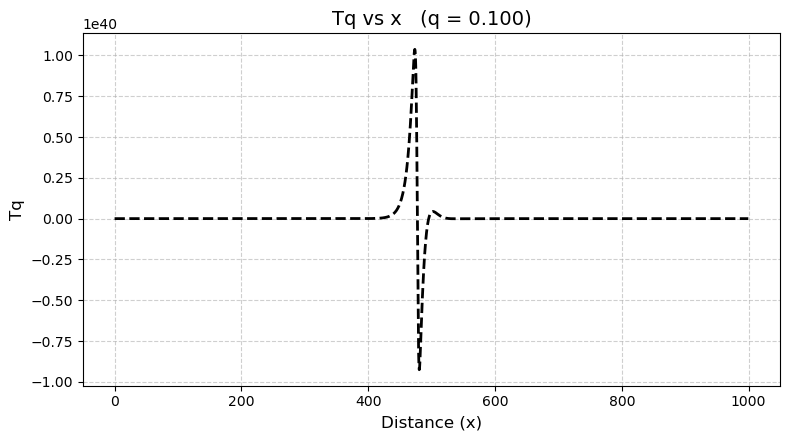

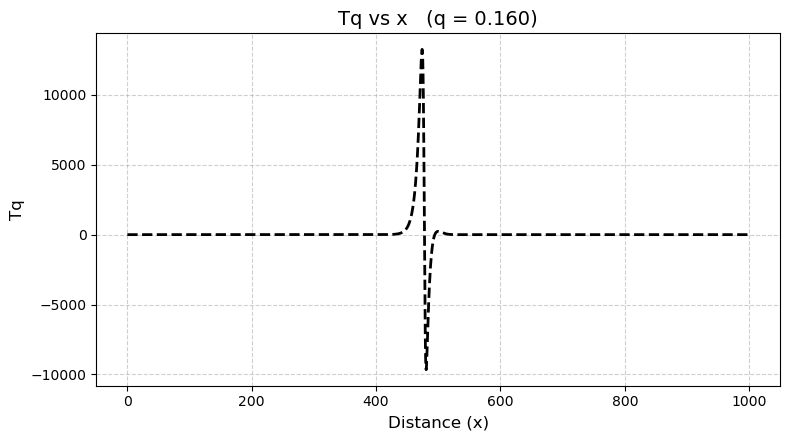

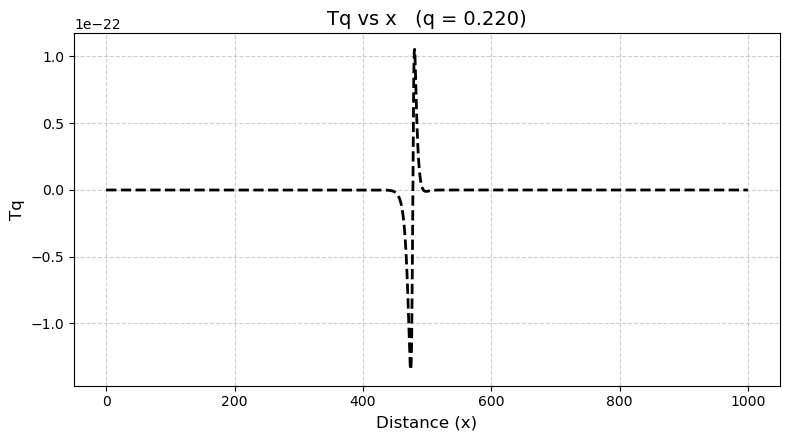

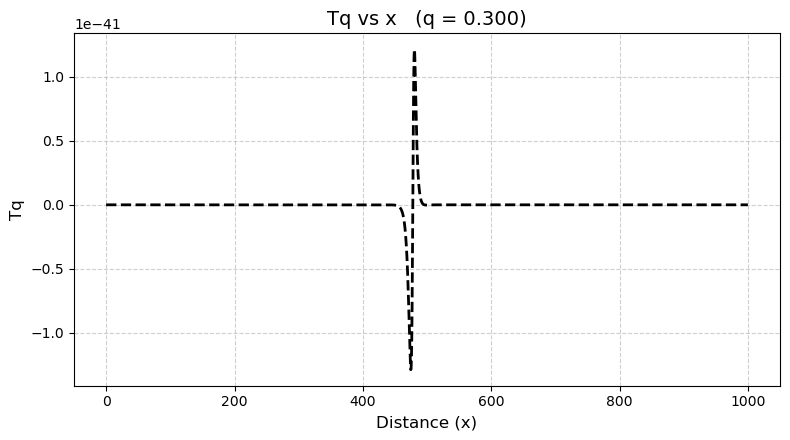

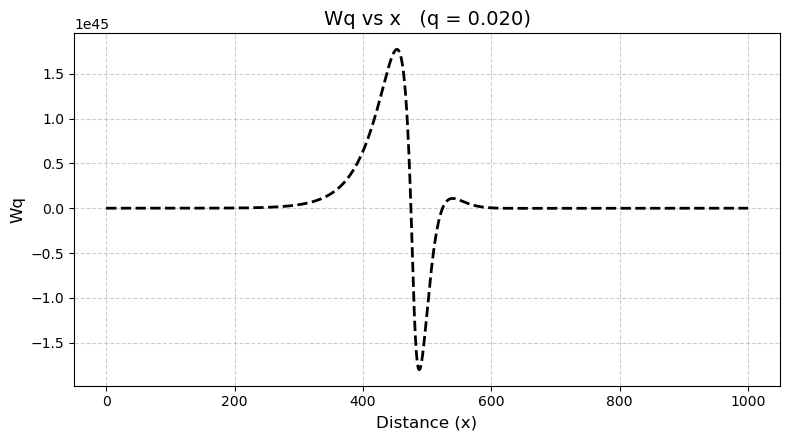

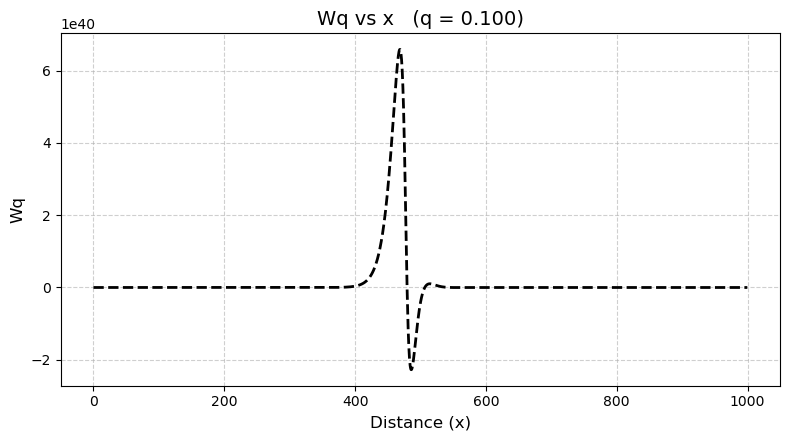

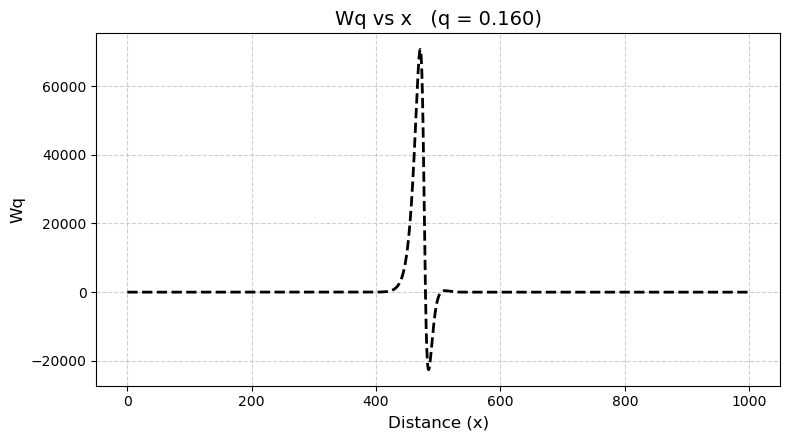

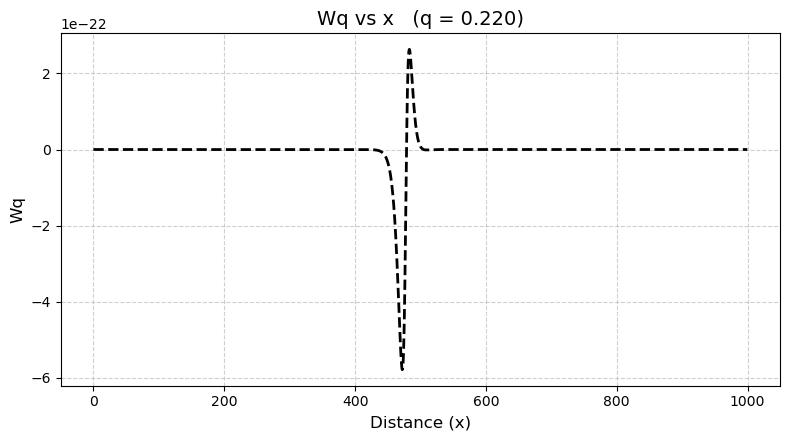

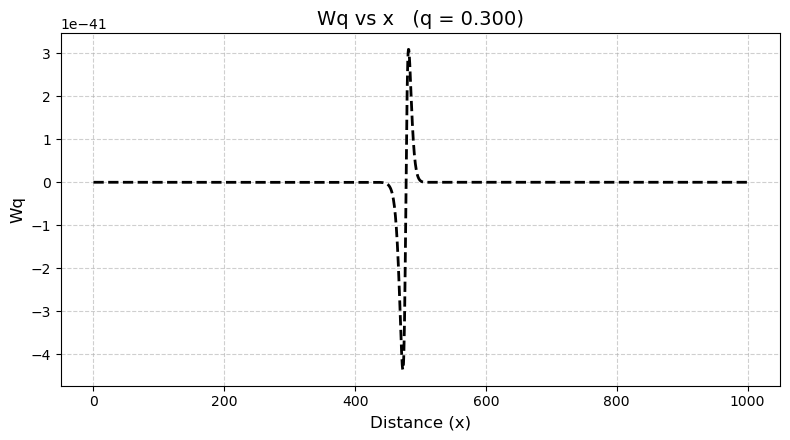

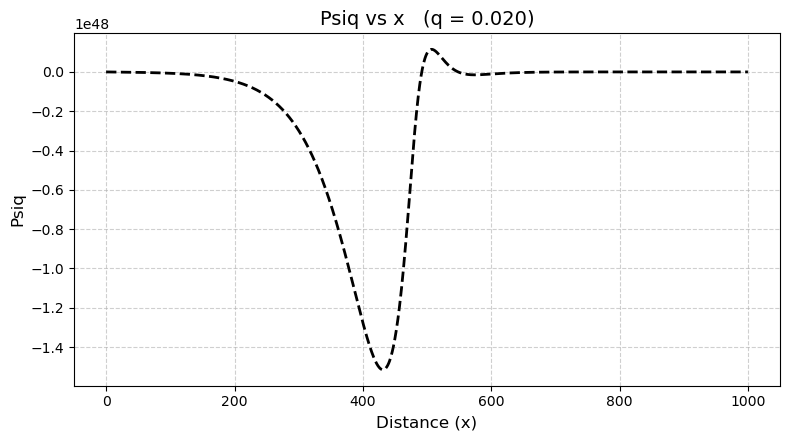

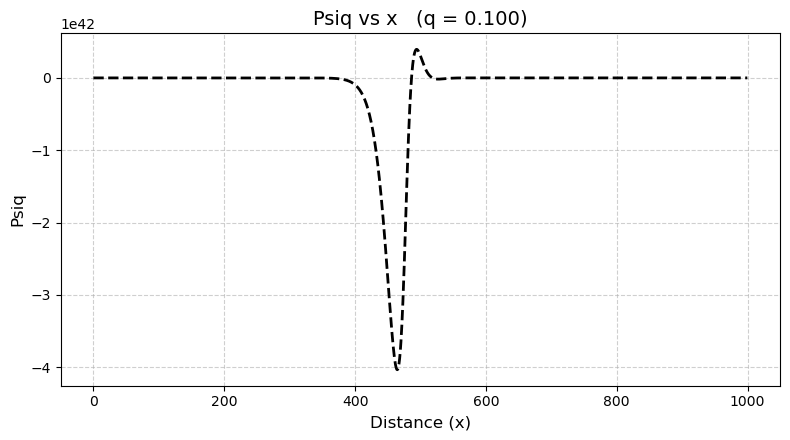

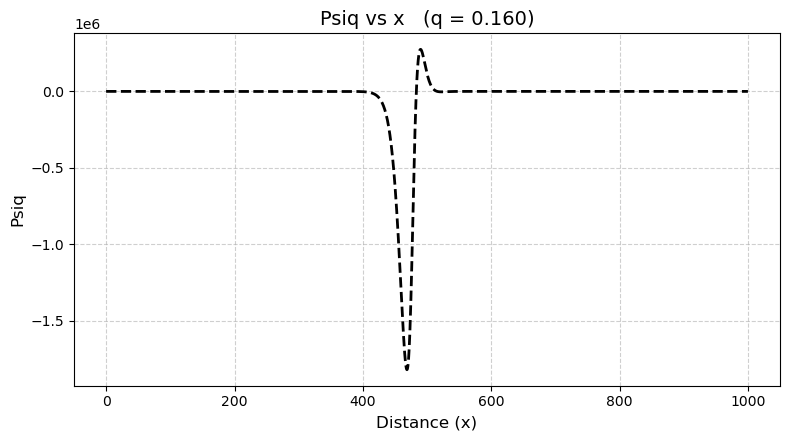

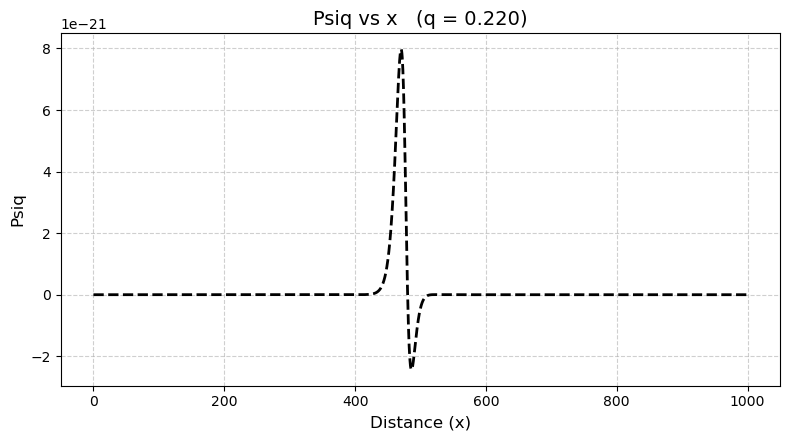

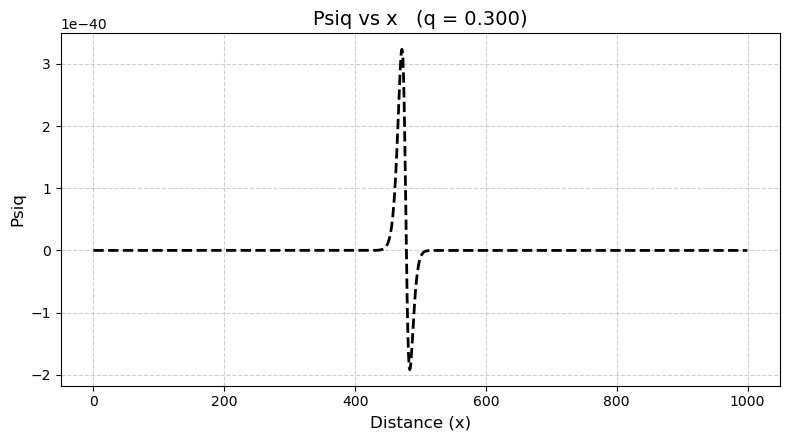

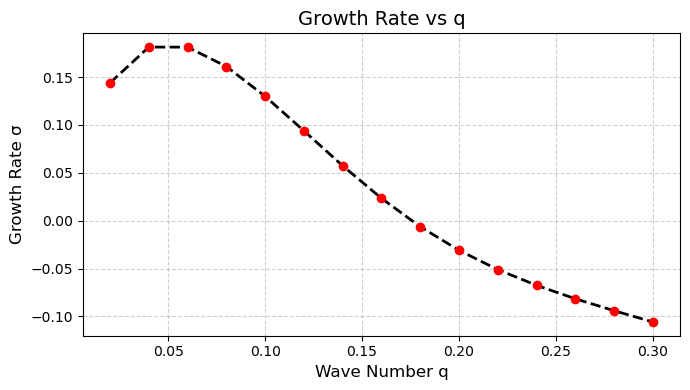

In [4]:
import numpy as np
import matplotlib.pyplot as plt

nx = 2000
nq = 15
dx = 0.5
q_max = 0.3
x = np.arange(nx) * dx
q_vals = np.arange(1, nq + 1) * (q_max / nq)

# --- carga de datos ---
C0      = np.loadtxt('C0_save.txt')
T0      = np.loadtxt('T0_save.txt')
Cq      = np.loadtxt('Cq_save.txt')
Tq      = np.loadtxt('Tq_save.txt')
Wq      = np.loadtxt('Wq_save.txt')
Psiq    = np.loadtxt('Psiq_save.txt')
growth  = np.loadtxt('growth_rate.txt')

variables = {
    'C0':   C0,
    'T0':   T0,
    'Cq':   Cq,
    'Tq':   Tq,
    'Wq':   Wq,
    'Psiq': Psiq
}

if nq <= 5:
    idx_field = np.arange(nq)
else:
    idx_field = np.round(np.linspace(0, nq - 1, 5)).astype(int)
idx_growth = np.arange(nq)

for name, mat in variables.items():
    for idx in idx_field:
        plt.figure(figsize=(8, 4.5))
        plt.plot(x, mat[:, idx], 'k--', linewidth=2)
        plt.xlabel('Distance (x)', fontsize=12)
        plt.ylabel(name, fontsize=12)
        plt.title(f'{name} vs x   (q = {q_vals[idx]:.3f})', fontsize=14)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()

plt.figure(figsize=(7, 4))
plt.plot(q_vals[idx_growth], growth[idx_growth], 'k--', linewidth=2, marker='o',
         markerfacecolor='red', markeredgecolor='red')
plt.xlabel('Wave Number q', fontsize=12)
plt.ylabel('Growth Rate σ', fontsize=12)
plt.title('Growth Rate vs q', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


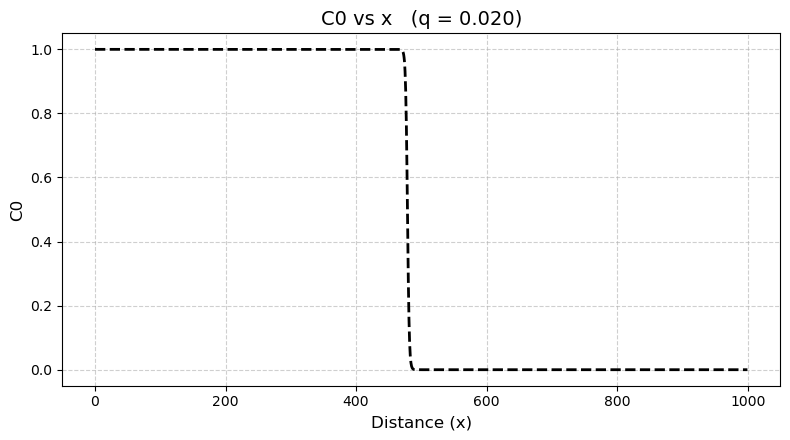

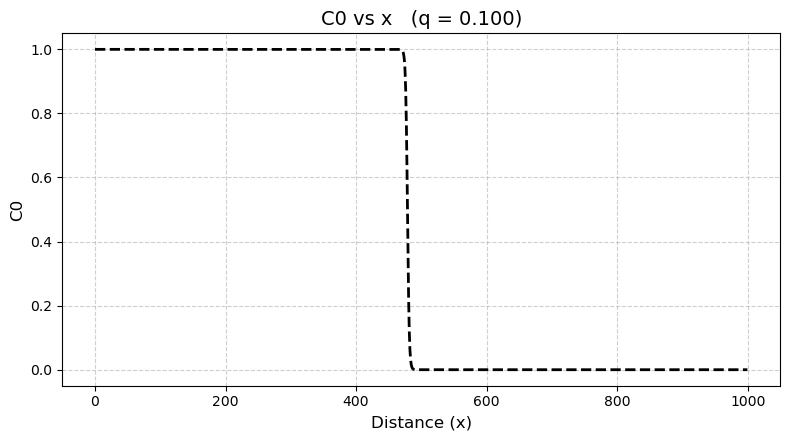

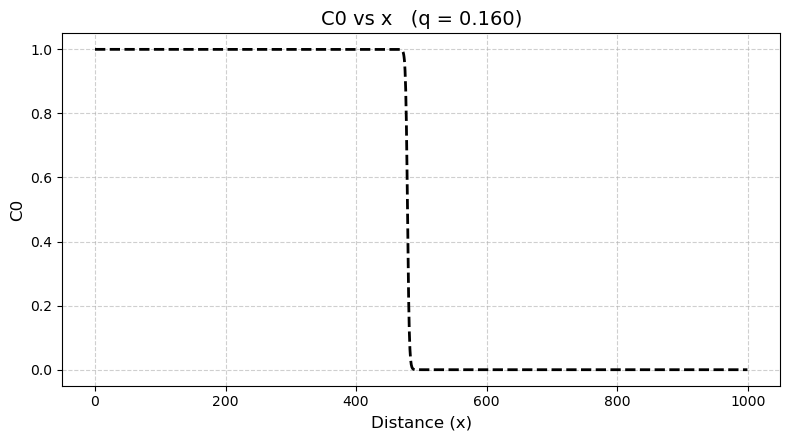

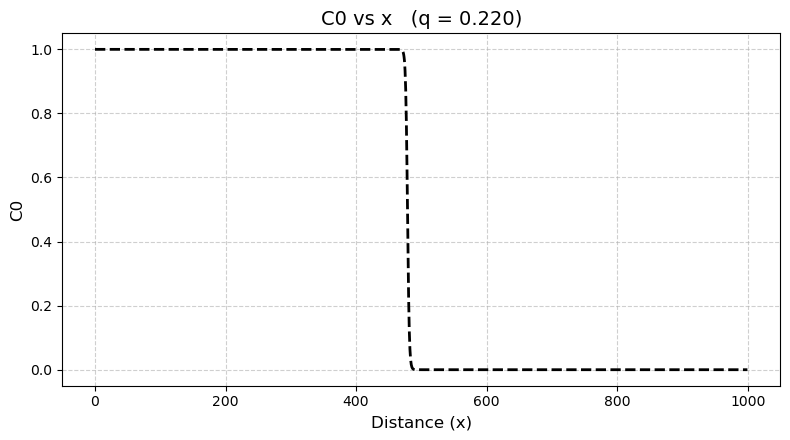

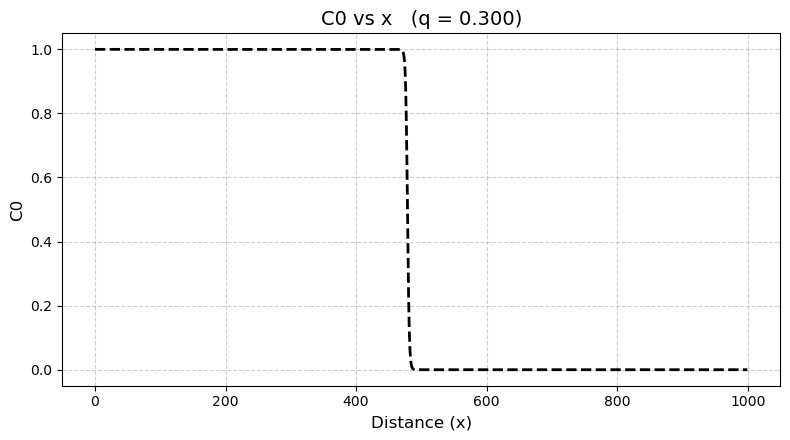

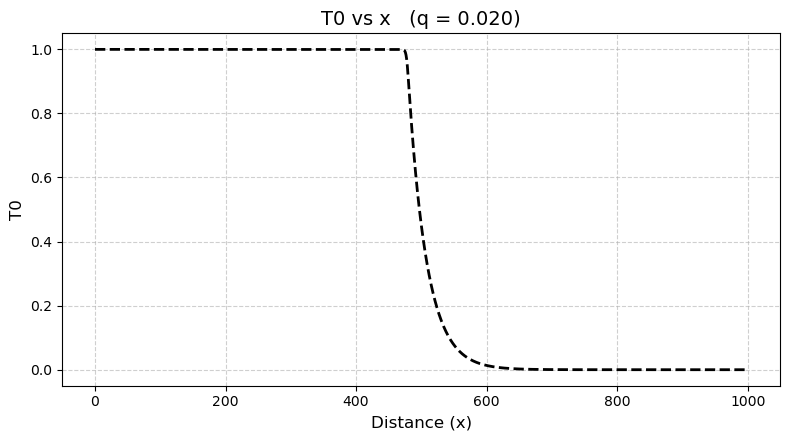

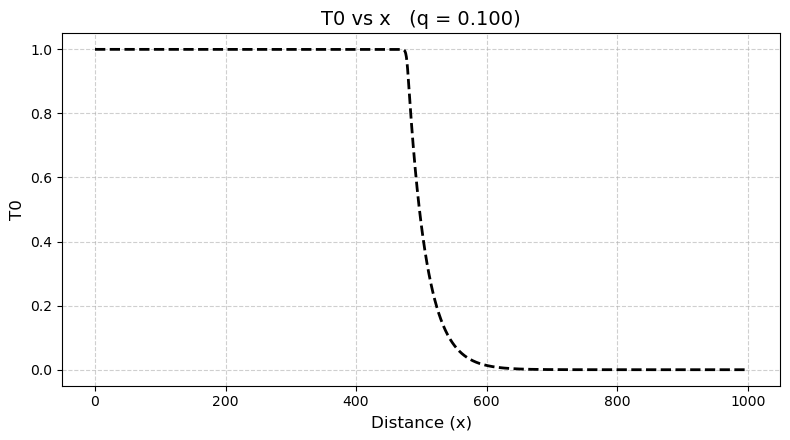

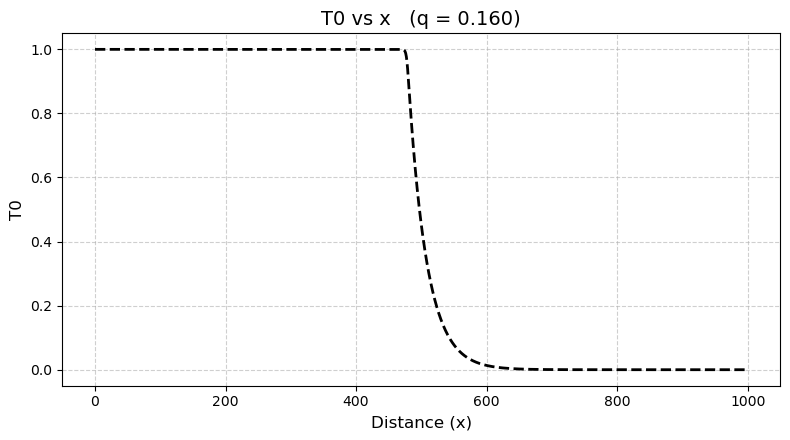

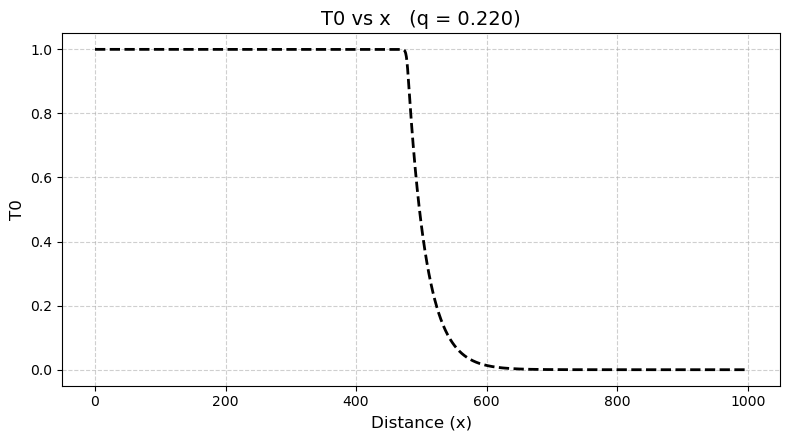

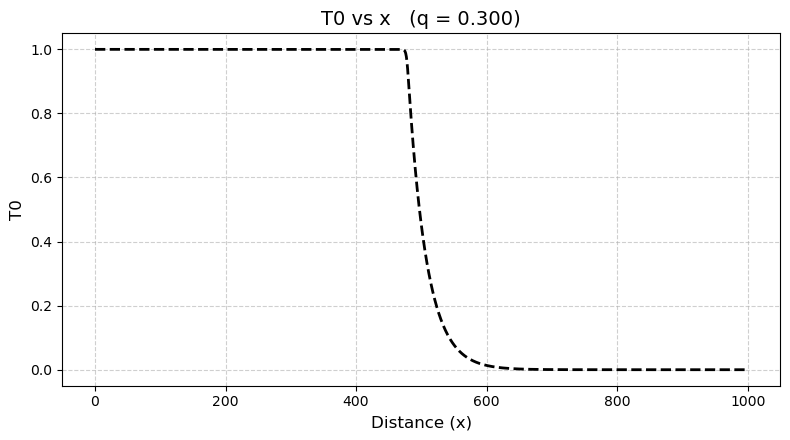

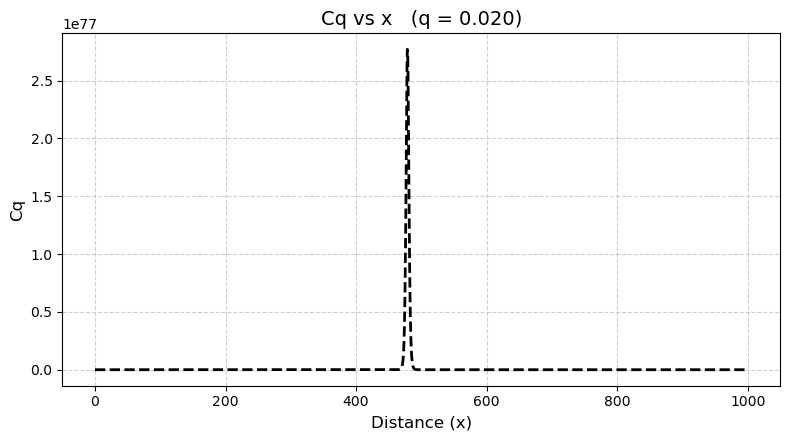

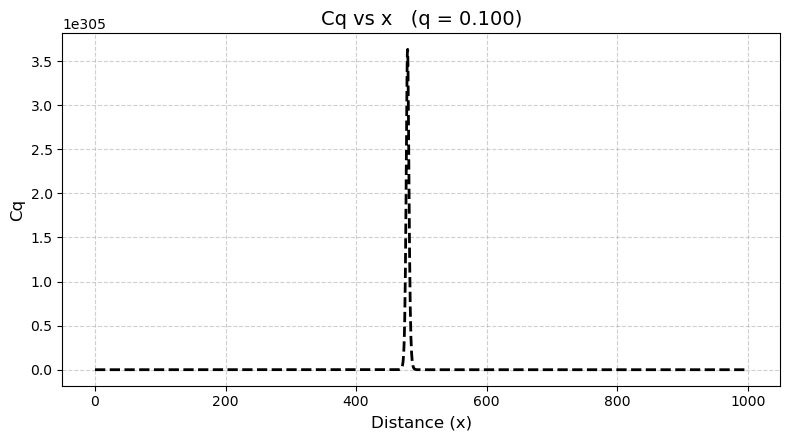

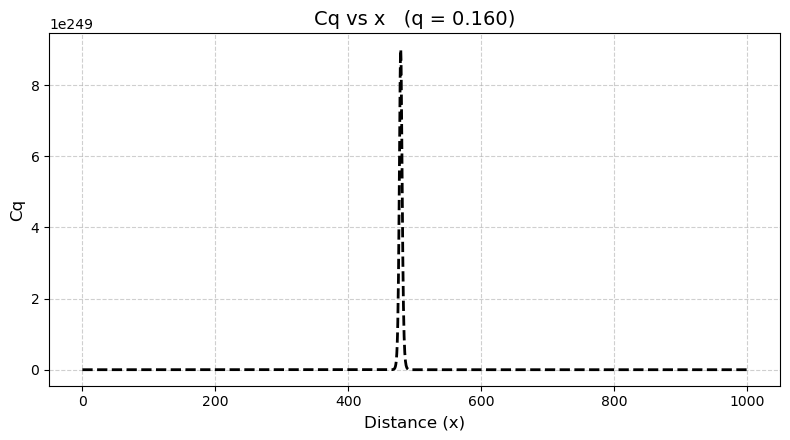

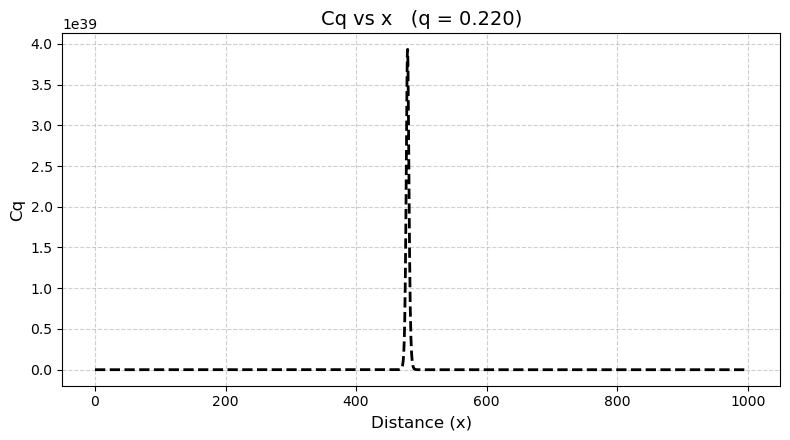

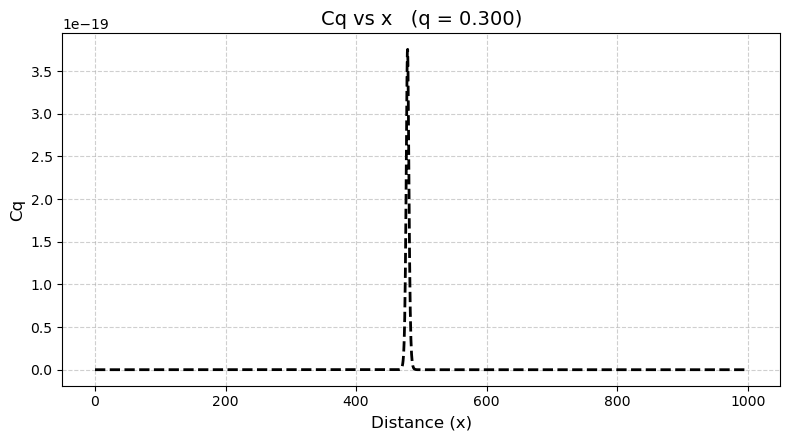

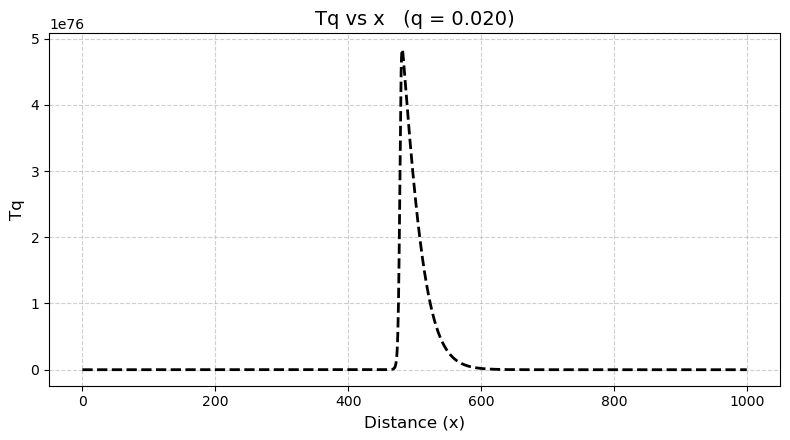

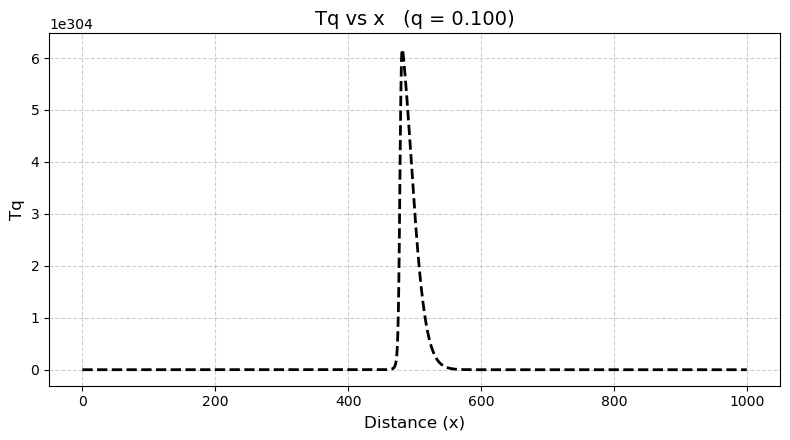

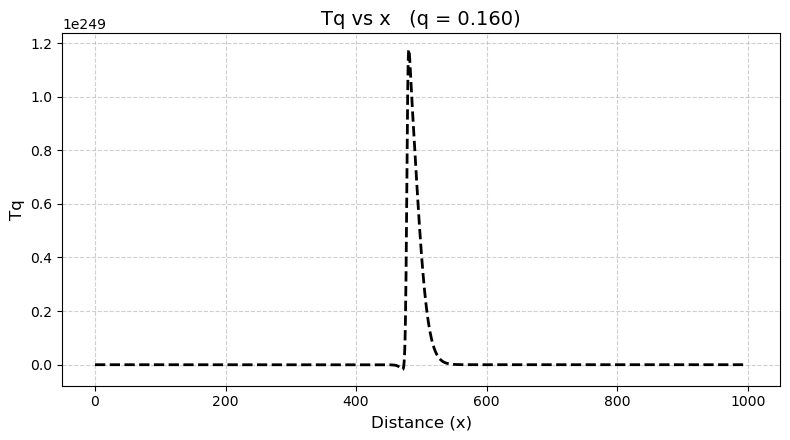

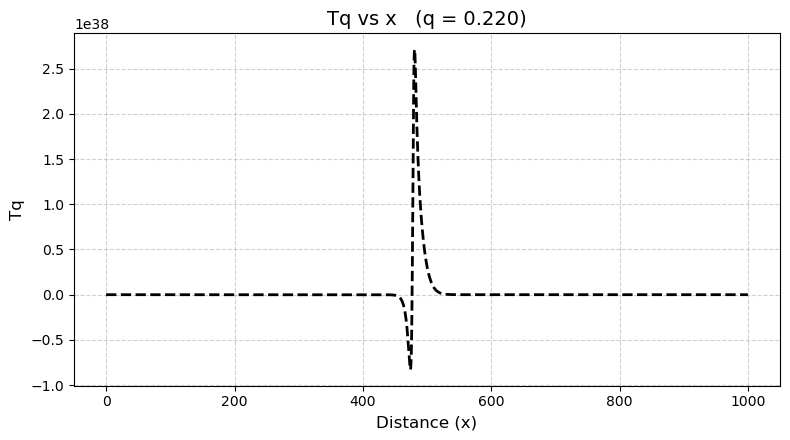

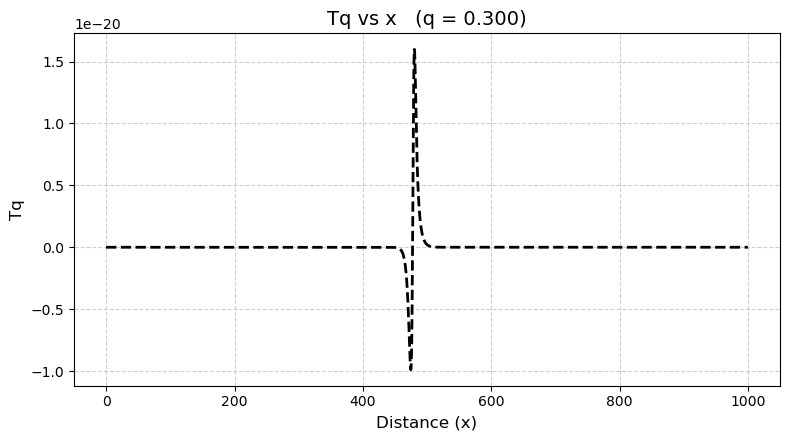

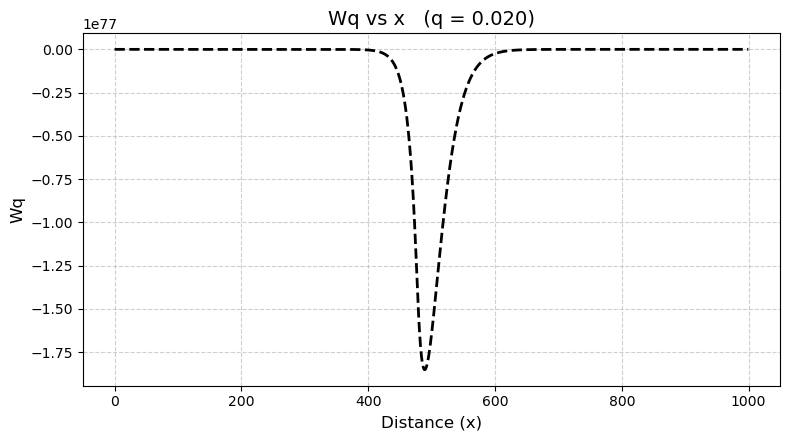

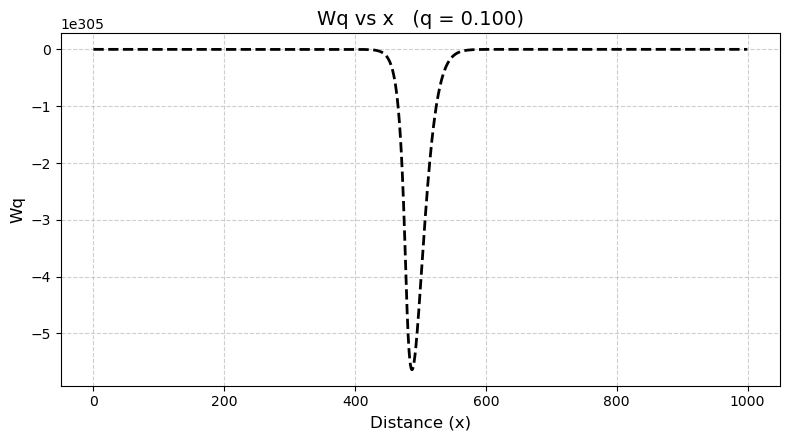

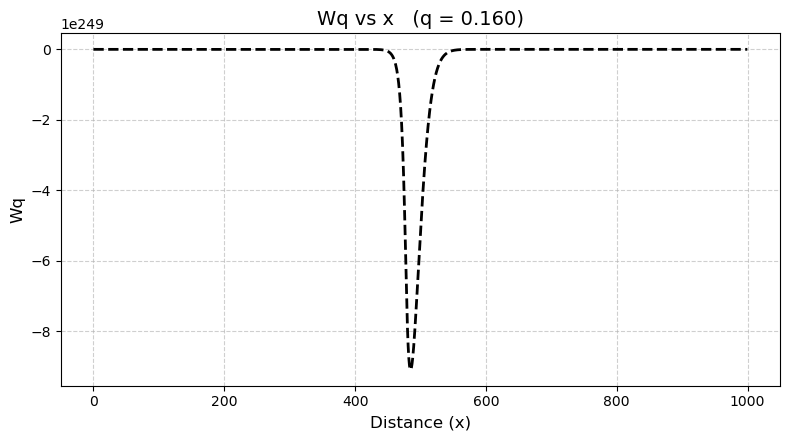

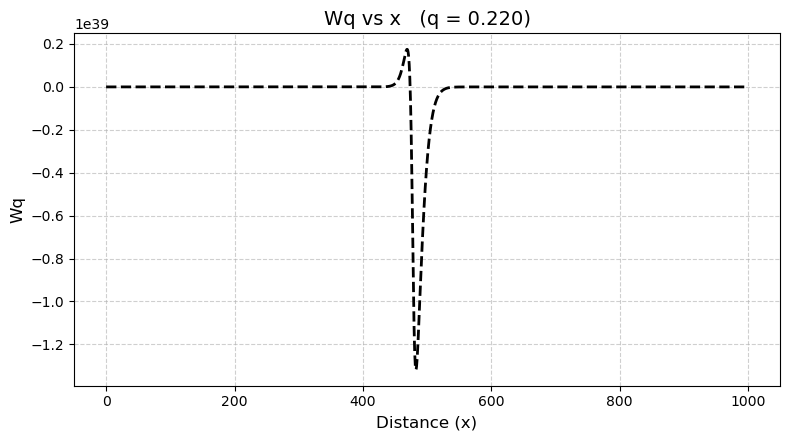

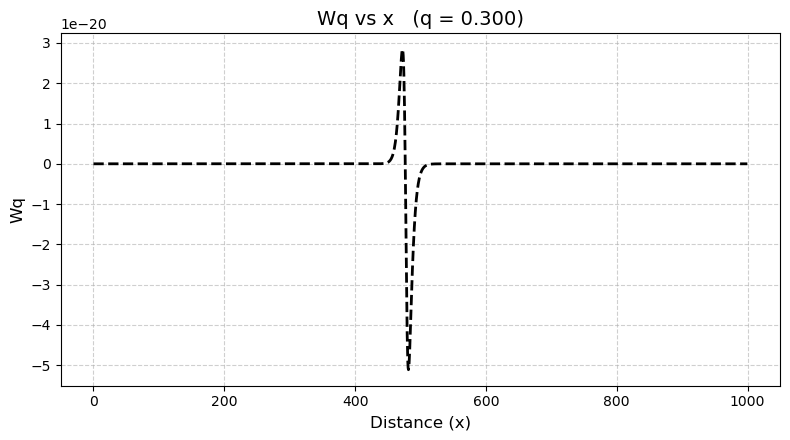

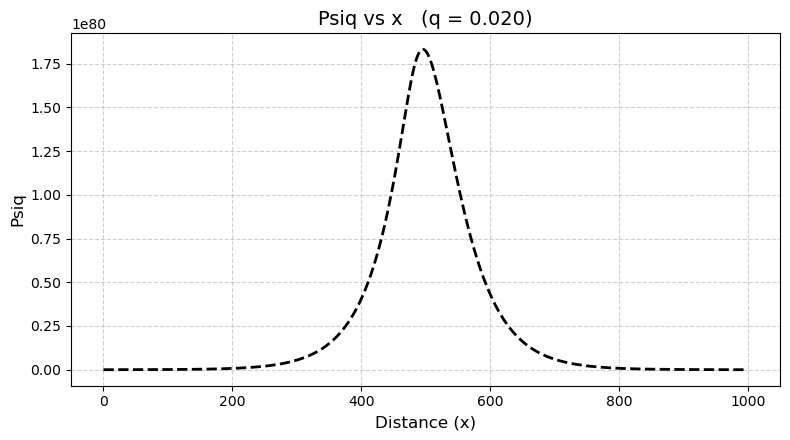

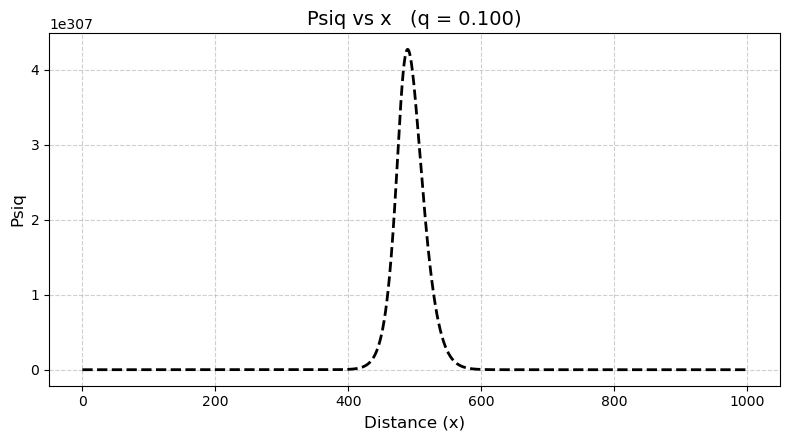

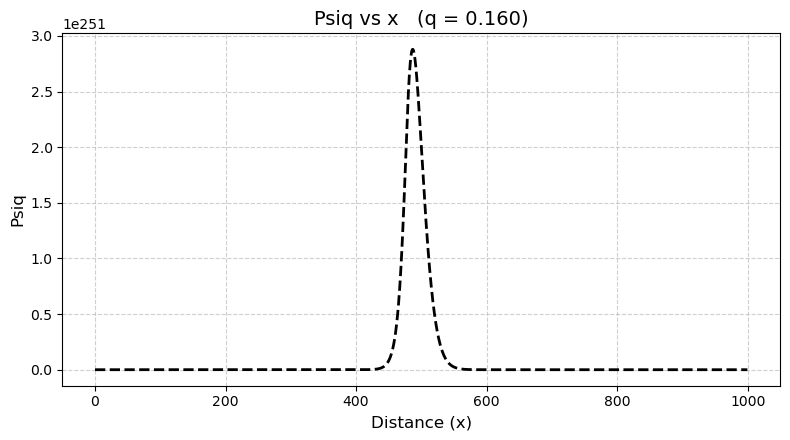

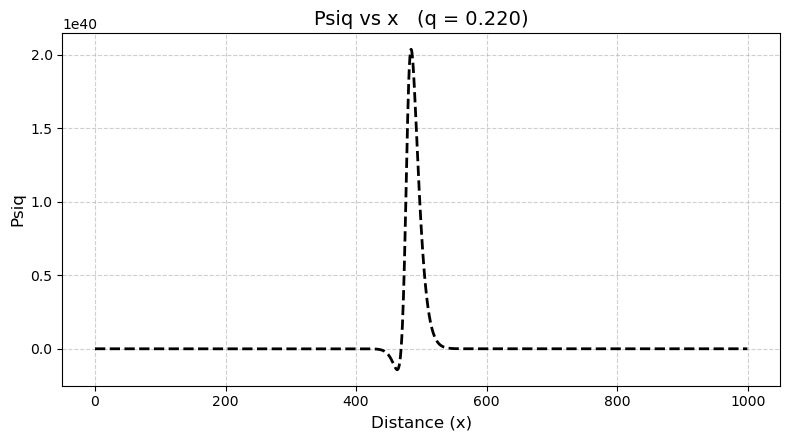

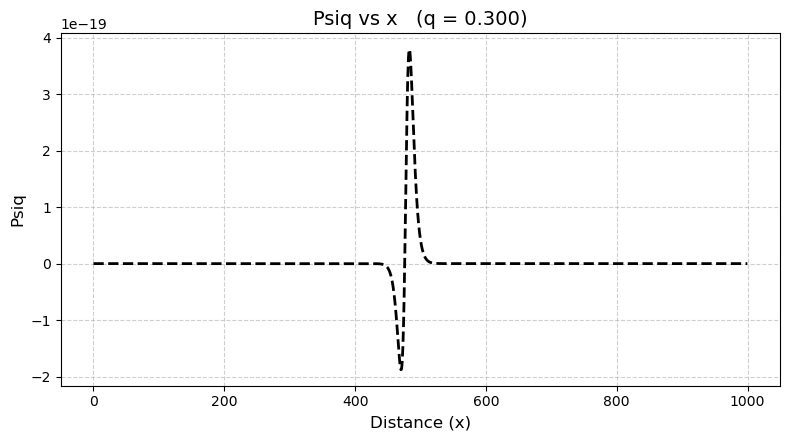

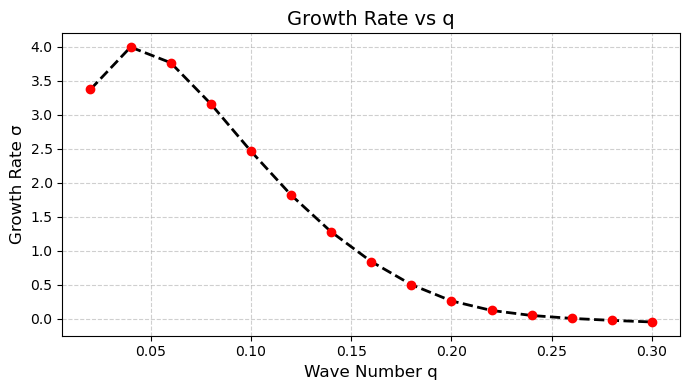

In [2]:
import numpy as np
import matplotlib.pyplot as plt

nx = 2000
nq = 15
dx = 0.5
q_max = 0.3
x = np.arange(nx) * dx
q_vals = np.arange(1, nq + 1) * (q_max / nq)

# --- carga de datos ---
C0      = np.loadtxt('C0_save.txt')
T0      = np.loadtxt('T0_save.txt')
Cq      = np.loadtxt('Cq_save.txt')
Tq      = np.loadtxt('Tq_save.txt')
Wq      = np.loadtxt('Wq_save.txt')
Psiq    = np.loadtxt('Psiq_save.txt')
growth  = np.loadtxt('growth_rate.txt')

variables = {
    'C0':   C0,
    'T0':   T0,
    'Cq':   Cq,
    'Tq':   Tq,
    'Wq':   Wq,
    'Psiq': Psiq
}

if nq <= 5:
    idx_field = np.arange(nq)
else:
    idx_field = np.round(np.linspace(0, nq - 1, 5)).astype(int)
idx_growth = np.arange(nq)

for name, mat in variables.items():
    for idx in idx_field:
        plt.figure(figsize=(8, 4.5))
        plt.plot(x, mat[:, idx], 'k--', linewidth=2)
        plt.xlabel('Distance (x)', fontsize=12)
        plt.ylabel(name, fontsize=12)
        plt.title(f'{name} vs x   (q = {q_vals[idx]:.3f})', fontsize=14)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()

plt.figure(figsize=(7, 4))
plt.plot(q_vals[idx_growth], growth[idx_growth], 'k--', linewidth=2, marker='o',
         markerfacecolor='red', markeredgecolor='red')
plt.xlabel('Wave Number q', fontsize=12)
plt.ylabel('Growth Rate σ', fontsize=12)
plt.title('Growth Rate vs q', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

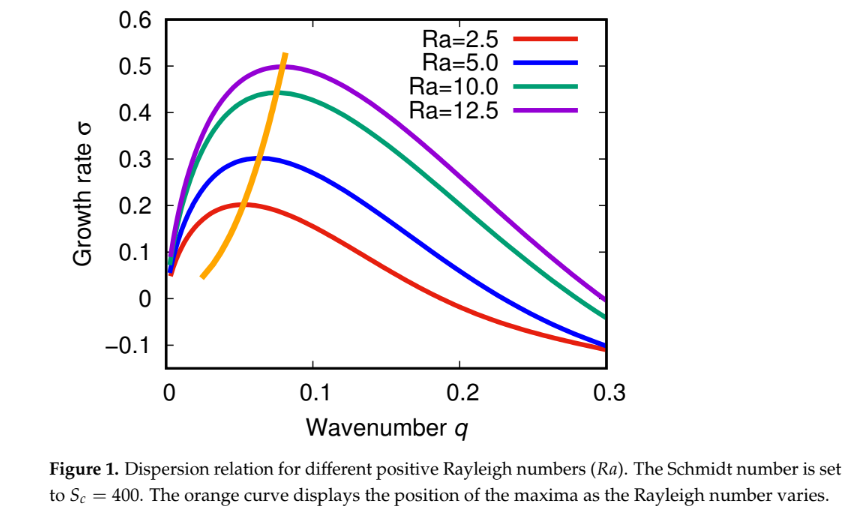

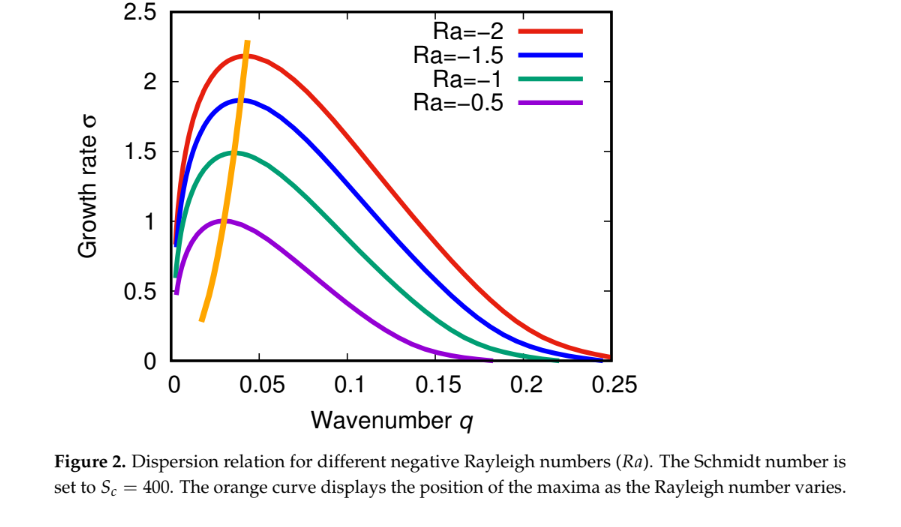

In [ ]:
#Mauricio Gutierrez 20195918
import numba
import numpy as np
import matplotlib.pyplot as plt
import time



# Normalización por máximo absoluto distinto de cero
def normalize(arr):
    max_val = np.max(np.abs(arr))
    return arr / max_val if max_val != 0 else arr
import numpy as np

# Uso de la libreria numba para maximizar eficiencia del codigo

# Función de resolución de un sistema tridiagonal
@numba.jit
def Tri(a,b,c,r):

    n = len(b)
    u = np.zeros(n)
    gam = np.zeros(n)
    
    bet = b[0]
    u[0] = r[0]/bet
    
    for i in range(1,n):
        gam[i] = c[i-1]/bet
        bet = b[i] - a[i]*gam[i]
    
        #if bet == 0 :
            #print("ERROR, beta must be differente from zero")
            
        u[i] = ( r[i] - a[i] * u[i-1] )/bet
    
    " Backsubstitution "
    
    for j in range(n-2,-1,-1):
        u[j] = u[j] - u[j+1]*gam[j+1]
    
    return u


#Funcion para hallar la tasa de crecimiento en función de q y Ra
@numba.jit
def Hallar_sigma(q,Ra,c,T):
    

    np.random.seed(1)
    # Variables que definen el tamaño del arreglo y los pasos
    nz = 2000
    t_pasos = 5000000
    dt = 0.0004
    dz = 0.5
    
    # Otorgo Le : número de Lewis y la velocidad del fluido en la dirección del eje X.
    Le = 20
    v0 = 1/np.sqrt(2) - 0.0023
    D = 1
    
    # Defino variables : número de Rayleigh, tasa de crecimiento, numero de onda, número de Schimdt
    #Ra = 2
    sigma_old = 0
    #sigma = np.zeros(100)
    #q = 0.0495
    Sc = 400
    
    # Defino las variables generales para resolver las ecuaciones
    a_prima = ( 2*Le/dz**2 )*dt
    b_prima = ( Le/dz**2 + v0/(2*dz) )*dt
    d_prima = ( Le/dz**2 - v0/(2*dz) )*dt
    
    a = ( 2*D/dz**2 )*dt
    b = ( D/dz**2 + v0/(2*dz) )*dt
    d = ( D/dz**2 - v0/(2*dz) )*dt
    
    # Defino la concentracion:
    #c = np.zeros(nz)
    #c[:960] = 1
    #c[960:1040] = 0.001 * np.random.random(80) 

    
    
    # Defino la Temperatura:
    #T = np.zeros(nz)
    #T[:960] = 1
    #T[960:1040] = 0.001*np.random.random(80)

    
    # Defino las variables C_q, T_q, W_q y Psi_q de la perturbación de primer orden en sus respectivos tiempo :

    Pq = np.zeros(nz)                       # Tiempo t
    
    Cq = np.zeros(nz)                       # Tiempo t  ----> tiempo t + delta t
    #Cq[:960] = 1
    Cq[960:1040] = 0.001*np.random.random(80)
  
    
    Tq = np.zeros(nz)                       # Tiempo t  ----> tiempo t + delta t
    #Tq[:960] = 1
    Tq[960:1040] = 0.001*np.random.random(80)
 

    Wq = np.zeros(nz)                      # Tiempot t - delta t ----> tiempo t

    
    # Valores para la resolución tridiagonal de Pq
    b4 = np.full(nz, - (2/dz**2 + q**2))
    a4 = np.full(nz, 1/(dz**2))
    #c4 = np.copy(a4)
    r4 = Wq
    
    # Valores para la resolución tridiagonal de Wq
    b3 = np.full(nz, Sc*q**2*dt + 1 + Sc*dt*2/dz**2 )
    c3 = np.full(nz, - (Sc*dt/dz**2 + v0*dt/(2*dz)))
    a3 = np.full(nz, - Sc*dt/dz**2 + v0*dt/(2*dz))
    r3 = Wq - q*Ra*Sc*dt*Tq
    
    
    
    # Definimos el primer máximo y el primer valor de t para hallar el sigma
    old_max = np.max(Cq)
    t_old = 0



    for t in range(t_pasos+1):
        #Guardaddo de la concentración en tiempo sin evolucionar
        c_old = c.copy()
        #Definicion de la funcion de reaccipn perturbada
        fc_old = c_old[1:-1]*(2 - 3*c_old[1:-1])
        # Iteraciones para hallar la evolución de la concentración
        c[1:-1] = c[2:]*b + c[1:-1]*(1 - a) + c[:-2]*d + (c[1:-1]**2*(1 - c[1:-1]))*dt
        # Condiciones de frontera actualizadas
        c[0] = c[1]
        c[-1] = 0

        #Guardado de la concentración Cq en tiempo sin evolucionar
        Cq_old = Cq.copy()

        
        #Evolución de Cq 
        Cq[1:-1] = Cq[1:-1]*( 1 - q**2*dt - 2*dt/dz**2 + fc_old*dt ) + Cq[2:]*(dt/dz**2 + v0*dt/(2*dz)) + Cq[:-2]*(dt/dz**2 - v0*dt/(2*dz)) + q*Pq[1:-1]*(c_old[2:] - c_old[:-2])*dt/(2*dz)
        #Condiciones de frontera
        Cq[0] = Cq[1]
        Cq[-1] = 0

        #Guardado de la temperatura en tiempo sin evolucionar
        T_old = T.copy()
        
        # Iteraciones para hallar la evolución de la temperatura
        T[1:-1] = T[2:]*b_prima + T[1:-1]*(1 - a_prima) + T[:-2]*d_prima + (c_old[1:-1]**2*(1-c_old[1:-1]))*dt
        # Condiciones de frontera
        T[0] = 1
        T[-1] = 0   
     
        # Iteraciones para hallar la evolución de la temperatura Tq
        Tq[1:-1] = Tq[1:-1]*(1 - Le*q**2*dt - 2*Le*dt/dz**2) + Tq[2:]*(Le*dt/dz**2 + v0*dt/(2*dz)) + Tq[:-2]*(Le*dt/dz**2 - v0*dt/(2*dz)) + q*Pq[1:-1]*(T_old[2:] - T_old[:-2])*dt/(2*dz) + fc_old*Cq_old[1:-1]*dt
        #Condiciones de frontera
        Tq[0] = Tq[1]
        Tq[-1] = 0
        
        # Evolución de la vorticidad
        Wq_ac = Wq.copy()
        r3 = Wq_ac - q*Ra*Sc*dt*Tq
        Wq = Tri(a3,b3,c3,r3)
        Wq[0] = 0
        Wq[-1] = 0
    
       
    
        # Evolucionar Psi_q desde tiempo t ----> tiempo t + delta t, esto nos ayuda a seguir evolucionando las demás soluciones dependientes de Psi_q
        Pq = Tri(a4,b4,a4,Wq)
        Pq[0] = 0
        Pq[-1] = 0
        if np.isnan(Cq).any():
            break
        if np.isnan(Tq).any():
            break
        if np.isnan(Pq).any():
            break
        if np.isnan(Wq).any():
            break

        # Calculo iterativo para hallar el sigma
        if (t%100==0) & (t > 100000):

            new_max = np.max(np.abs(Cq))
            if new_max == 0:
                break
            sigma = (new_max - old_max)/(old_max*(t-t_old)*dt)
            diff = np.abs(sigma-sigma_old)
            if (diff < 10**-6)  :
                break
            
            sigma_old = sigma
            t_old = t        
            old_max = new_max
    return sigma,Cq,Tq,Wq,Pq,c,T,t

@numba.jit
def valores_grafica(q_arr,Ra_arr,c,T):
    np.random.seed(1)

    sigma_val = np.zeros((len(Ra_arr),2,len(q_arr)))
    sigma_val[:,1] = q_arr
    c0 = c
    t0 = T
    Ra_idx = 0   
    
    for Ra in Ra_arr:
        q_idx = 0        
        for q in q_arr:
            sigma = Hallar_sigma(q,Ra,c0,t0)[0]
            sigma_val[Ra_idx,0,q_idx] = sigma
            q_idx +=1            
        Ra_idx+=1
        
    return sigma_val



# Array para depositar valores de sigma por cada q , con su respectivo Ra
# [sigma,q],[sigma,q],[sigma,q],[sigma,q]
Ra_arr = np.array([-0.5,-1.0,-1.5,-2.0])
q_arr = np.linspace(0,0.3,31)
c0_5M = np.loadtxt('C0_5M.txt')
T0_5M = np.loadtxt('T0_5M.txt')


start = time.time()
sigma_val = valores_grafica(q_arr,Ra_arr,c0_5M,T0_5M)

end = time.time()
duracion = end - start
minutos = int((duracion)/60)
segundos = (duracion)%60
print(f"Tiempo de ejecución total: {minutos:02d}:{segundos:04.1f}\n")

np.savetxt('Data/Sistem_ec/Ra(-0.5)/sigma(q).txt',sigma_val[0])
np.savetxt('Data/Sistem_ec/Ra(-1.0)/sigma(q).txt',sigma_val[1])
np.savetxt('Data/Sistem_ec/Ra(-1.5)/sigma(q).txt',sigma_val[2])
np.savetxt('Data/Sistem_ec/Ra(-2.0)/sigma(q).txt',sigma_val[3])


plt.plot(q_arr,sigma_val[0][0],label = 'Ra = -0.5')
plt.plot(q_arr,sigma_val[1][0],label = 'Ra = -1.0')
plt.plot(q_arr,sigma_val[2][0],label = 'Ra = -1.5')
plt.plot(q_arr,sigma_val[3][0],label = 'Ra = -2.0')
plt.title('Dispersion Relation')
plt.xlabel('Wavelength q')
plt.ylabel(r'Growth rate $\sigma$')
plt.legend()
plt.show()
